    Time  Spirit0_x  Spirit0_y  Spirit0_z  Spirit1_x  Spirit1_y  Spirit1_z  \
0  1.502   0.000000   0.000000   0.190000   1.000000   0.250000   0.190000   
1  1.503   0.000014  -0.000003   0.189993   0.999986   0.250003   0.189993   
2  1.504   0.000205  -0.000065   0.189996   0.999740   0.250047   0.190004   
3  1.505   0.000869  -0.000322   0.189920   0.998809   0.250213   0.189993   
4  1.506   0.001891  -0.000686   0.189826   0.997567   0.250493   0.189971   

   Spirit2_x  Spirit2_y  Spirit2_z  Unnamed: 10  
0   0.000000    2.00000   0.190000          NaN  
1   0.000002    2.00000   0.189993          NaN  
2   0.000058    2.00002   0.190013          NaN  
3   0.000267    2.00008   0.190050          NaN  
4   0.000564    2.00018   0.190092          NaN  


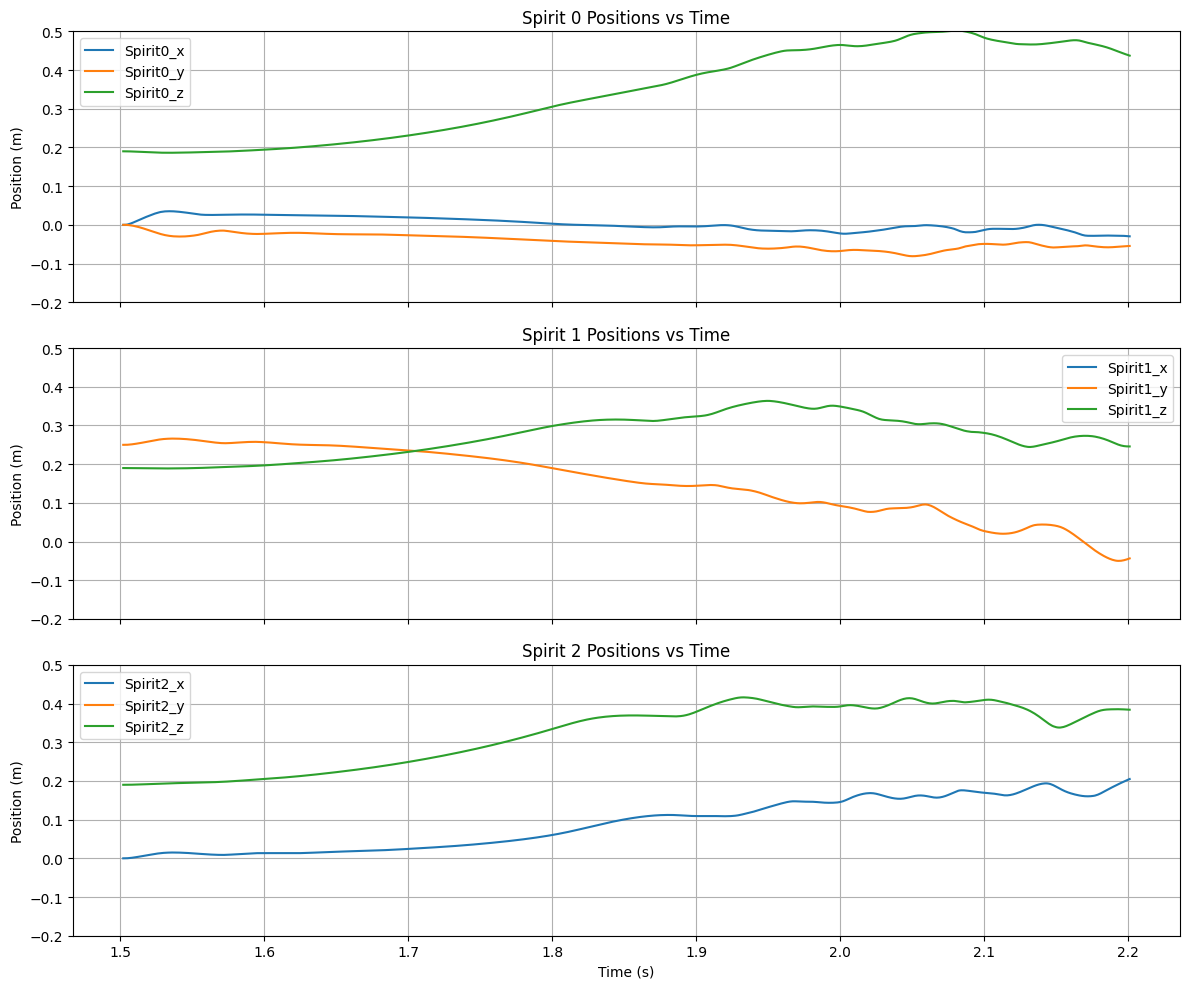

In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file (assumes it's already in the current directory)
csv_file = "spirit_positions.csv"
df = pd.read_csv(csv_file)

# Check the first few rows to verify the data loaded correctly
print(df.head())

# Extract columns
time = df["Time"]
spirit0_x = df["Spirit0_x"]
spirit0_y = df["Spirit0_y"]
spirit0_z = df["Spirit0_z"]

spirit1_x = df["Spirit1_x"]
spirit1_y = df["Spirit1_y"]
spirit1_z = df["Spirit1_z"]

spirit2_x = df["Spirit2_x"]
spirit2_y = df["Spirit2_y"]
spirit2_z = df["Spirit2_z"]

# Create a figure with three subplots (one for each spirit)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot for Spirit 0
axes[0].plot(time, spirit0_x, label="Spirit0_x")
axes[0].plot(time, spirit0_y, label="Spirit0_y")
axes[0].plot(time, spirit0_z, label="Spirit0_z")
axes[0].set_title("Spirit 0 Positions vs Time")
axes[0].set_ylabel("Position (m)")
axes[0].set_ylim(-0.2, 0.5)  # Set y-axis range
axes[0].legend()
axes[0].grid(True)

# Plot for Spirit 1
axes[1].plot(time, spirit1_x, label="Spirit1_x")
axes[1].plot(time, spirit1_y, label="Spirit1_y")
axes[1].plot(time, spirit1_z, label="Spirit1_z")
axes[1].set_title("Spirit 1 Positions vs Time")
axes[1].set_ylabel("Position (m)")
axes[1].set_ylim(-0.2, 0.5)  # Set y-axis range
axes[1].legend()
axes[1].grid(True)

# Plot for Spirit 2
axes[2].plot(time, spirit2_x, label="Spirit2_x")
axes[2].plot(time, spirit2_y, label="Spirit2_y")
axes[2].plot(time, spirit2_z, label="Spirit2_z")
axes[2].set_title("Spirit 2 Positions vs Time")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Position (m)")
axes[2].set_ylim(-0.2, 0.5)  # Set y-axis range
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# ----------------------------
# Step 1: Load CSV Data and Preprocess
# ----------------------------
df = pd.read_csv("spirit_positions.csv")
print("Original data shape:", df.shape)
print("Columns:", df.columns)

# Explicitly select only the needed columns.
# Adjust these names if your CSV uses different ones.
required_columns = ["Time", "Spirit0_x", "Spirit0_y", "Spirit0_z",
                    "Spirit1_x", "Spirit1_y", "Spirit1_z",
                    "Spirit2_x", "Spirit2_y", "Spirit2_z"]
df = df.loc[:, required_columns]
print("Data shape after selecting required columns:", df.shape)

# Fill missing values using forward-fill then backward-fill.
df = df.ffill().bfill()
print("Total NaNs after filling:", df.isnull().sum().sum())

# ----------------------------
# Step 2: Prepare the Data
# ----------------------------
X = df[["Time"]].values      # shape: (n_samples, 1)
y = df.drop(columns=["Time"]).values  # shape: (n_samples, 9)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Any NaNs in X?", np.isnan(X).sum())
print("Any NaNs in y?", np.isnan(y).sum())

# ----------------------------
# Step 3: Split Data (70% Train, 30% Test)
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# ----------------------------
# Step 4: Train Multiple Machine Learning Models
# ----------------------------
def train_and_evaluate(model, X_train, y_train, X_test, y_test, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    accuracy_percent = r2 * 100
    print(f"{name} - MSE: {mse:.4f}, R^2 Accuracy: {accuracy_percent:.2f}%")
    return model

# Train traditional ML models
lin_reg = MultiOutputRegressor(LinearRegression())
lin_reg = train_and_evaluate(lin_reg, X_train, y_train, X_test, y_test, name="Linear Regression")

rf_reg = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
rf_reg = train_and_evaluate(rf_reg, X_train, y_train, X_test, y_test, name="Random Forest")

gb_reg = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100, random_state=42))
gb_reg = train_and_evaluate(gb_reg, X_train, y_train, X_test, y_test, name="Gradient Boosting")

svr_reg = MultiOutputRegressor(SVR(kernel='rbf', C=100, epsilon=0.1))
svr_reg = train_and_evaluate(svr_reg, X_train, y_train, X_test, y_test, name="SVR")

# ----------------------------
# Step 5: Train a Deep Learning Model (Keras)
# ----------------------------
model_dl = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(y_train.shape[1])  # output layer with 9 neurons
])
model_dl.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model_dl.fit(X_train, y_train,
                       validation_split=0.2,
                       epochs=100,
                       batch_size=32,
                       callbacks=[early_stop],
                       verbose=0)

# Evaluate deep learning model
y_pred_dl = model_dl.predict(X_test)
r2_dl = r2_score(y_test, y_pred_dl)
accuracy_dl = r2_dl * 100
print(f"Deep Learning - MSE: {mean_squared_error(y_test, y_pred_dl):.4f}, R^2 Accuracy: {accuracy_dl:.2f}%")

# ----------------------------
# Step 6: Testing: Input and Predicted Output
# ----------------------------
# Prompt the user for a new time input.
user_input = input("Enter a time value in seconds to predict robot positions: ")
try:
    t_input = float(user_input)
except ValueError:
    print("Invalid input! Please enter a valid number.")
    t_input = 0.0

X_new = np.array([[t_input]])

print("\nPredicted positions (x,y,z for all 3 robots) for time =", t_input, "seconds:")

print("Linear Regression prediction:")
print(lin_reg.predict(X_new))

print("Random Forest prediction:")
print(rf_reg.predict(X_new))

print("Gradient Boosting prediction:")
print(gb_reg.predict(X_new))

print("SVR prediction:")
print(svr_reg.predict(X_new))

print("Deep Learning prediction:")
print(model_dl.predict(X_new))

# ----------------------------
# Step 7: Optionally, Show Summary of Accuracies
# ----------------------------
print("\nSummary of Model Accuracies (R^2 in %):")
print("Linear Regression:", r2_score(y_test, lin_reg.predict(X_test)) * 100)
print("Random Forest:", r2_score(y_test, rf_reg.predict(X_test)) * 100)
print("Gradient Boosting:", r2_score(y_test, gb_reg.predict(X_test)) * 100)
print("SVR:", r2_score(y_test, svr_reg.predict(X_test)) * 100)
print("Deep Learning:", accuracy_dl)

/Users/nathanzhang/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Original data shape: (700, 11)
Columns: Index(['Time', 'Spirit0_x', 'Spirit0_y', 'Spirit0_z', 'Spirit1_x', 'Spirit1_y',
       'Spirit1_z', 'Spirit2_x', 'Spirit2_y', 'Spirit2_z', 'Unnamed: 10'],
      dtype='object')
Data shape after selecting required columns: (700, 10)
Total NaNs after filling: 0
Shape of X: (700, 1)
Shape of y: (700, 9)
Any NaNs in X? 0
Any NaNs in y? 0
Linear Regression - MSE: 0.0005, R^2 Accuracy: 81.99%
Random Forest - MSE: 0.0000, R^2 Accuracy: 99.98%
Gradient Boosting - MSE: 0.0000, R^2 Accuracy: 99.94%
SVR - MSE: 0.0028, R^2 Accuracy: 8.65%


/Users/nathanzhang/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Deep Learning - MSE: 0.0022, R^2 Accuracy: -154.48%

Predicted positions (x,y,z for all 3 robots) for time = 1.0 seconds:
Linear Regression prediction:
[[ 0.06764057  0.02182751 -0.12671903  0.92281264  0.52050021  0.12869039
  -0.1769504   2.08346164  0.02231844]]
Random Forest prediction:
[[ 3.14455340e-04 -1.24720196e-04  1.89966730e-01  9.99594880e-01
   2.50087950e-01  1.89992530e-01  9.68819400e-05  2.00003620e+00
   1.90015360e-01]]
Gradient Boosting prediction:
[[ 3.26115531e-04 -4.25836066e-04  1.89704183e-01  9.99705335e-01
   2.50405947e-01  1.89804092e-01  5.82454483e-04  2.00019851e+00
   1.90377871e-01]]
SVR prediction:
[[ 0.0027561  -0.040515    0.34398497  0.987068    0.10817162  0.276273
   0.10245821  1.983785    0.30343138]]
Deep Learning prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[ 0.08057675 -0.03865001  0.05040028  0.8090718   0.46782026  0.12747617
   0.05390936  1.6486692   0.11432304]]

Summary of Model Accuracies (